# 👩‍💻 Data Imputation Lab: Cleaning a Customer Purchase Dataset


## 📋 Overview
In this lab, you'll tackle the crucial task of cleaning a customer purchase dataset by addressing missing data. You'll apply various imputation techniques and make decisions about when to remove or replace missing values, preparing the dataset for use in machine learning models. These skills are essential for real-world data science roles where data rarely arrives in a clean, complete state.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Identify and visualize patterns of missing data in datasets
- Apply appropriate imputation techniques based on data characteristics
- Evaluate the impact of imputation methods on data integrity
- Make informed decisions about handling missing values in preparation for machine learning

## 🚀 Starting Point
Access the starter code below.

Required tools/setup:

- Python 3.x
- Pandas, NumPy, Matplotlib libraries
- scikit-learn


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # For enhanced visualizations
from sklearn.impute import SimpleImputer

# --- Data Loading and Initial Examination ---
print("--- Loading and Examining Data ---")

# Load the dataset

try:
    data = pd.read_csv('sample_dataset.csv')
    print("Dataset loaded successfully.")
    print("Shape of Dataset: ", data.shape)
    display(data.head(2))
except FileNotFoundError:
    print("Error: sample_dataset.csv not found. Please check download/unzip.")
    exit() # Exit if data loading fails

--- Loading and Examining Data ---
Dataset loaded successfully.
Shape of Dataset:  (50000, 9)


,Customer ID,Name,Surname,Gender,Birthdate,Transaction Amount,Date,Merchant Name,Category
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic
1,26381,Michelle,Phelps,NaN,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",Travel


## Task 1: Examine the Dataset
**Context:** Data scientists often begin with exploratory data analysis to understand the structure, content, and quality of their data. This helps identify potential problems, including missing values, before proceeding with analysis.

**Steps:**

1. Use Pandas functions like `head()`, `describe()`, and `info()` to explore the dataset structure.


2. Identify the columns containing missing values using the `isnull().sum()` method.


3. Calculate the percentage of missing values for each column to understand the extent of the issue.

In [2]:
# Your code for loading and examining the dataset
# Display first few rows
# Count missing values per column

print("\nDataset Info:")
data.info()
print("="*100)
print()

print("\nFirst 5 rows:")
display(data.head())
print("="*100)
print()

print("\nMissing values per column:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])
print("="*100)
print()

print("\nPercentage of missing values:")
missing_percentage = (missing_values / len(data)) * 100
print(missing_percentage[missing_percentage > 0])
print("="*100)
print()

print("\nSummary of Data:")
display(data.describe().T)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer ID         50000 non-null  int64  
 1   Name                50000 non-null  object 
 2   Surname             50000 non-null  object 
 3   Gender              44953 non-null  object 
 4   Birthdate           50000 non-null  object 
 5   Transaction Amount  50000 non-null  float64
 6   Date                50000 non-null  object 
 7   Merchant Name       50000 non-null  object 
 8   Category            50000 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 3.4+ MB


First 5 rows:


,Customer ID,Name,Surname,Gender,Birthdate,Transaction Amount,Date,Merchant Name,Category
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic
1,26381,Michelle,Phelps,NaN,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",Travel
2,305449,Jacob,Williams,M,1981-10-25,115.97,2023-09-20,Steele Inc,Clothing
3,988259,Nathan,Snyder,M,1977-10-26,11.31,2023-01-11,"Wilson, Wilson and Russell",Cosmetic
4,764762,Crystal,Knapp,F,1951-11-02,62.21,2023-06-13,Palmer-Hinton,Electronics




Missing values per column:
Gender    5047
dtype: int64


Percentage of missing values:
Gender    10.094
dtype: float64


Summary of Data:


,count,mean,std,min,25%,50%,75%,max
Customer ID,50000.0,500136.796960,288232.431640,29.00,251191.5000,499520.500,749854.250,999997.00
Transaction Amount,50000.0,442.119239,631.669724,5.01,79.0075,182.195,470.515,2999.88


**💡 Tip:** Look for patterns in the missing data. Are certain columns missing more values than others? Are there rows with multiple missing values?

**⚙️ Test Your Work:**
- Your output should show the dataset structure, summary statistics, and a count of missing values by column.
- Verify that you can identify which columns have the highest percentage of missing values.

## Task 2: Visualize Missing Data
**Context:** Visualization helps identify patterns in missing data that might not be obvious from numerical summaries. These patterns can inform your imputation strategy.

**Steps:**

1. Create a bar chart showing the count of missing values for each column.


2. Optional: Consider creating any other visualizations as needed.


--- Visualizing Missing Data ---


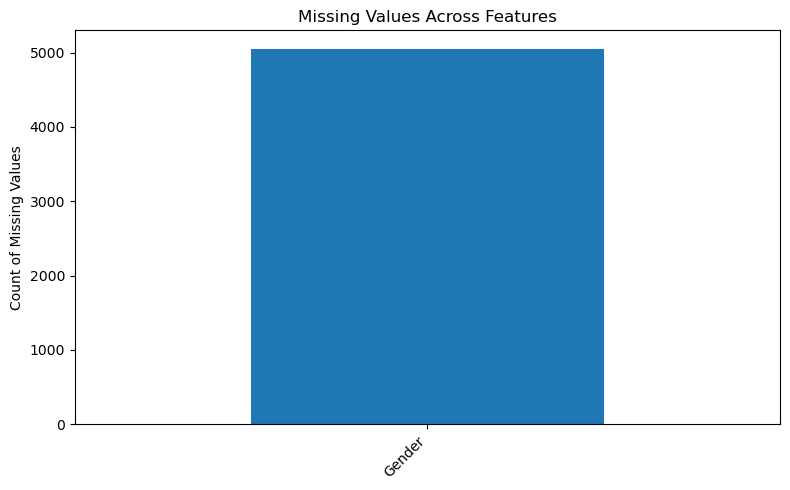

In [3]:
# Your code for visualizing missing data
# Create bar chart of missing values
# Optional: Create additional visualizations


print("\n--- Visualizing Missing Data ---")


if missing_values[missing_values > 0].empty:
    print("No missing values to visualize.")
else:
    plt.figure(figsize=(8, 5))
    missing_values[missing_values > 0].plot(kind='bar')
    plt.ylabel('Count of Missing Values')
    plt.title('Missing Values Across Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**💡 Tip:** Pay attention to whether missing values appear randomly distributed or follow patterns that might suggest issues with data collection.

**⚙️ Test Your Work:**
- Your visualization clearly shows which columns have missing values and their relative proportions.
- You can identify any patterns in the missing data that might influence your imputation strategy.


## Task 3: Implement Basic Imputation Methods
**Context:** Simple imputation techniques like mean or median replacement are often suitable first approaches for handling missing numerical data.

**Steps:**
1. **Split the data** into training and testing sets using `train_test_split`. Remember to split features (X) and target (y) separately if you have a target variable, or just split the main DataFrame if not predicting a target (though typically you would). Imputation is applied to the features (X).


2. Identify which columns are **numerical** and which are **categorical** and have missing values.


3. For the **numerical columns** with missing values, use `SimpleImputer` with `strategy='mean'` or `strategy='median'`.


4. For **categorical columns** with missing values, use `SimpleImputer` with `strategy='most_frequent'`.


5. **Combine these strategies** using a `ColumnTransformer` to apply the correct imputer to the correct subset of columns.


6. **Fit the** `ColumnTransformer` **ONLY on the training data.**


7. **Transform BOTH the training and testing data** using the fitted transformer.

In [4]:
# Your code for basic imputation techniques
# Implement mean imputation
# Implement median imputation
# Compare results

print("\n--- Implementing Basic Imputation Methods ---")
data_imputed = data.copy() # Create a copy to work on


# Impute 'Gender' (Categorical) with 'most_frequent'
if 'Gender' in data_imputed.columns and data_imputed['Gender'].isnull().sum() > 0:
    print("\nImputing 'Gender' with mode...")
    gender_imputer = SimpleImputer(strategy='most_frequent')
    # Apply imputer and flatten the 2D output
    data_imputed['Gender'] = gender_imputer.fit_transform(data_imputed[['Gender']])[:, 0]
    print("'Gender' imputation complete.")
else:
     print("\nNo missing values in 'Gender'. Skipping mode imputation.")


--- Implementing Basic Imputation Methods ---

Imputing 'Gender' with mode...
'Gender' imputation complete.


In [5]:
print("\nDemonstrating mean/median imputation on 'Transaction Amount' (no NaNs):")
numeric_col_demo = 'Transaction Amount'
if numeric_col_demo in data_imputed.columns:
    # Mean Imputation Demo
    data_imputed_mean_demo = data.copy()
    mean_imputer = SimpleImputer(strategy='mean')
    data_imputed_mean_demo[numeric_col_demo] = mean_imputer.fit_transform(data_imputed_mean_demo[[numeric_col_demo]])[:, 0]
    print(f"'{numeric_col_demo}' mean imputation demo complete.")


    # Median Imputation Demo
    data_imputed_median_demo = data.copy()
    median_imputer = SimpleImputer(strategy='median')
    data_imputed_median_demo[numeric_col_demo] = median_imputer.fit_transform(data_imputed_median_demo[[numeric_col_demo]])[:, 0]
    print(f"'{numeric_col_demo}' median imputation demo complete.")
else:
    print(f"Warning: Numeric demo column '{numeric_col_demo}' not found.")


Demonstrating mean/median imputation on 'Transaction Amount' (no NaNs):
'Transaction Amount' mean imputation demo complete.
'Transaction Amount' median imputation demo complete.


**💡 Tip:** Consider whether mean or median imputation is more appropriate based on the distribution of each column. Skewed distributions often benefit from median imputation.

**⚙️ Test Your Work:**
- Verify that no missing values remain after imputation.
- Compare summary statistics before and after imputation to assess the impact on data distribution.


## Task 4: Evaluate the Impact on Dataset
**Context:** After imputation, it's crucial to evaluate how the techniques have affected the dataset's statistical properties.

**Steps:**

1. Generate descriptive statistics for each imputed dataset (mean and median).


2. Create visualizations (histograms or box plots) to compare distributions before and after imputation.


3. Assess whether the imputation techniques have preserved the overall data structure and relationships.

In [6]:
# Your code for evaluating imputation impact
# Generate descriptive statistics for each imputed dataset
# Create comparative visualizations
# Note observations about the impact

print("\nMissing values after imputation on 'Gender':")
print(data_imputed.isnull().sum()['Gender']) # Should be 0


print("\n'Gender' distribution before and after mode imputation:")
print("Original:")
print(data['Gender'].value_counts(dropna=False))
print("\nAfter Mode Imputation:")
print(data_imputed['Gender'].value_counts(dropna=False)) # dropna=False to show the change


Missing values after imputation on 'Gender':
0

'Gender' distribution before and after mode imputation:
Original:
F      22713
M      22240
NaN     5047
Name: Gender, dtype: int64

After Mode Imputation:
F    27760
M    22240
Name: Gender, dtype: int64



Descriptive stats for 'Transaction Amount':


'Original:'

,count,mean,std,min,25%,50%,75%,max
Transaction Amount,50000.0,442.119239,631.669724,5.01,79.0075,182.195,470.515,2999.88


'Mean Demo:'

,count,mean,std,min,25%,50%,75%,max
Transaction Amount,50000.0,442.119239,631.669724,5.01,79.0075,182.195,470.515,2999.88


'Median Demo:'

,count,mean,std,min,25%,50%,75%,max
Transaction Amount,50000.0,442.119239,631.669724,5.01,79.0075,182.195,470.515,2999.88


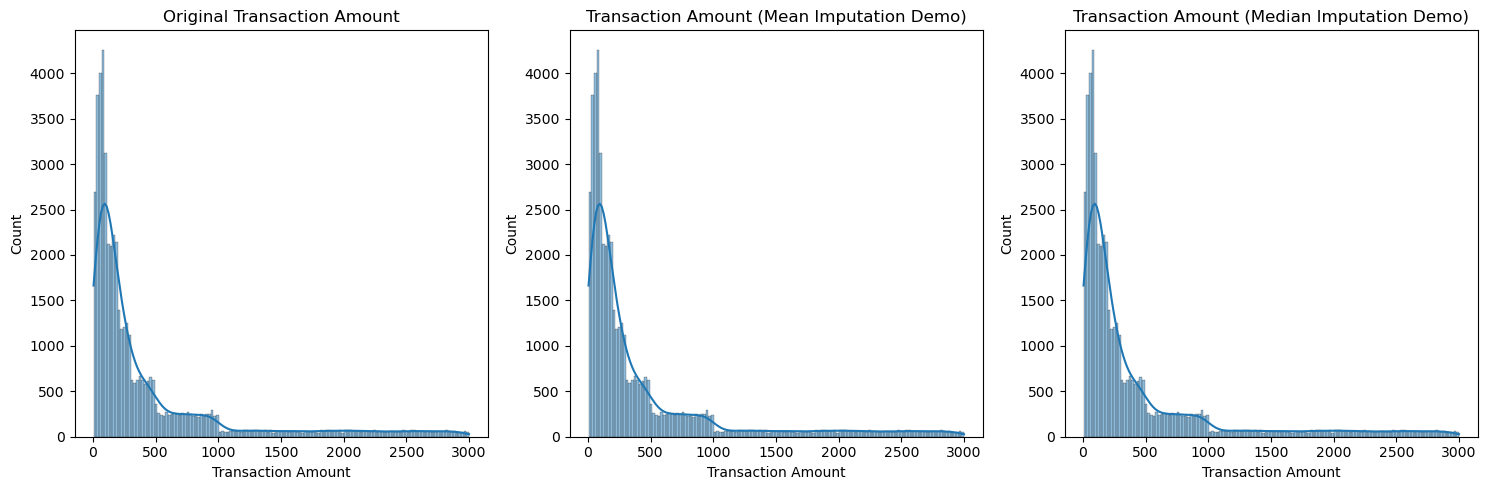

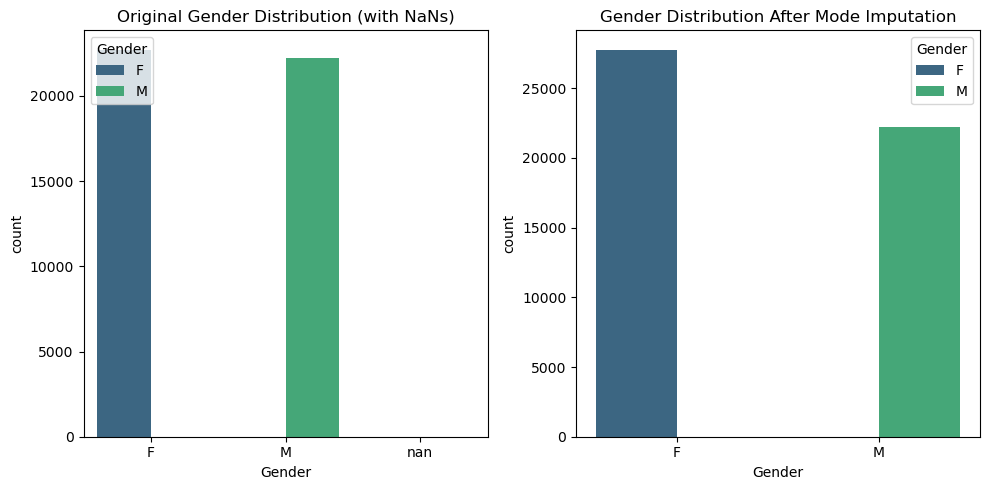

In [7]:
# Evaluate numeric demo imputation impact (expected to be minimal as no NaNs)
if numeric_col_demo in data_imputed.columns:
    print(f"\nDescriptive stats for '{numeric_col_demo}':")
    display("Original:", data[[numeric_col_demo]].describe().T)
    display("Mean Demo:", data_imputed_mean_demo[[numeric_col_demo]].describe().T)
    display("Median Demo:", data_imputed_median_demo[[numeric_col_demo]].describe().T)


    # Comparative Histograms for the numeric demo column
    plt.figure(figsize=(15, 5))


    plt.subplot(1, 3, 1)
    sns.histplot(data=data, x=numeric_col_demo, kde=True)
    plt.title(f'Original {numeric_col_demo}')


    plt.subplot(1, 3, 2)
    sns.histplot(data=data_imputed_mean_demo, x=numeric_col_demo, kde=True)
    plt.title(f'{numeric_col_demo} (Mean Imputation Demo)')


    plt.subplot(1, 3, 3)
    sns.histplot(data=data_imputed_median_demo, x=numeric_col_demo, kde=True)
    plt.title(f'{numeric_col_demo} (Median Imputation Demo)')


    plt.tight_layout()
    plt.show()


    # Comparative Count Plots for Gender distribution
    plt.figure(figsize=(10, 5))


    plt.subplot(1, 2, 1)
    sns.countplot(data=data, x='Gender', order=data['Gender'].value_counts(dropna=False).index, palette='viridis', hue='Gender')
    plt.title('Original Gender Distribution (with NaNs)')


    plt.subplot(1, 2, 2)
    sns.countplot(data=data_imputed, x='Gender', order=data_imputed['Gender'].value_counts().index, palette='viridis', hue='Gender')
    plt.title('Gender Distribution After Mode Imputation')


    plt.tight_layout()
    plt.show()

**💡 Tip:** Look for significant changes in mean, median, or distribution shape that might indicate the imputation has distorted the data.

**⚙️ Test Your Work:**
- Your analysis should show how each imputation technique has affected the dataset's statistical properties.
- You can identify which technique preserved the data's integrity best.

## ✅ Success Checklist
- Successfully loaded and examined the dataset, identifying columns with missing values
- Created clear visualizations showing the distribution of missing data
- Implemented and compared mean and median imputation techniques
- Evaluated the impact of different imputation techniques on data integrity
- Documented your approach and findings throughout the process
- Code runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Imputation dramatically changes the distribution of a column.

**Solution:** This often indicates that the chosen imputation method isn't appropriate. Try an alternative method or consider whether the column should be handled differently.

**Problem:** Missing values in categorical columns cannot be handled with mean/median imputation.

**Solution:** For categorical data, consider mode imputation or creating a new "Missing" category.

## 🔑 Key Points
- Different imputation techniques work better for different data distributions.
- Visualizing missing data patterns helps inform appropriate imputation strategies.
- Evaluating the impact of imputation is crucial to ensure data integrity is maintained.
- When dealing with skewed data, median imputation often preserves the distribution better than mean.

## ➡️ Next Steps
In your next lab, you'll build on these data cleaning skills by exploring feature engineering techniques that prepare your cleaned data for machine learning algorithms. You'll learn how to transform variables, create new features, and select the most relevant attributes for model training.


## 💻 Exemplar Solution

<details>
<summary><strong>Click HERE to see an examplar solution</summary><strong>

```python
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # For enhanced visualizations
from sklearn.impute import SimpleImputer

# --- Data Loading and Initial Examination ---
print("--- Loading and Examining Data ---")


# Load the dataset
try:
    data = pd.read_csv('sample_dataset.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: sample_dataset.csv not found. Please check download/unzip.")
    exit() # Exit if data loading fails


print("\nDataset Info:")
data.info()


print("\nFirst 5 rows:")
print(data.head())


print("\nMissing values per column:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0]) # Print only columns with missing values


print("\nPercentage of missing values:")
missing_percentage = (missing_values / len(data)) * 100
print(missing_percentage[missing_percentage > 0]) # Print percentage for columns with missing data


# --- Visualize Missing Data ---
print("\n--- Visualizing Missing Data ---")


if missing_values[missing_values > 0].empty:
    print("No missing values to visualize.")
else:
    plt.figure(figsize=(8, 5))
    missing_values[missing_values > 0].plot(kind='bar')
    plt.ylabel('Count of Missing Values')
    plt.title('Missing Values Across Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# --- Implement Basic Imputation Methods ---
print("\n--- Implementing Basic Imputation Methods ---")


# Based on examination, only 'Gender' has missing values and is categorical.
# 'Transaction Amount' is numeric but has no NaNs - used here for mean/median demo.


data_imputed = data.copy() # Create a copy to work on


# Impute 'Gender' (Categorical) with 'most_frequent'
if 'Gender' in data_imputed.columns and data_imputed['Gender'].isnull().sum() > 0:
    print("\nImputing 'Gender' with mode...")
    gender_imputer = SimpleImputer(strategy='most_frequent')
    # Apply imputer and flatten the 2D output
    data_imputed['Gender'] = gender_imputer.fit_transform(data_imputed[['Gender']])[:, 0]
    print("'Gender' imputation complete.")
else:
     print("\nNo missing values in 'Gender'. Skipping mode imputation.")


# Demonstrate Mean/Median Imputation (for numeric columns if they had NaNs)
# Applying to 'Transaction Amount' as a demo, though it has no NaNs.
print("\nDemonstrating mean/median imputation on 'Transaction Amount' (no NaNs):")
numeric_col_demo = 'Transaction Amount'
if numeric_col_demo in data_imputed.columns:
    # Mean Imputation Demo
    data_imputed_mean_demo = data.copy()
    mean_imputer = SimpleImputer(strategy='mean')
    data_imputed_mean_demo[numeric_col_demo] = mean_imputer.fit_transform(data_imputed_mean_demo[[numeric_col_demo]])[:, 0]
    print(f"'{numeric_col_demo}' mean imputation demo complete.")


    # Median Imputation Demo
    data_imputed_median_demo = data.copy()
    median_imputer = SimpleImputer(strategy='median')
    data_imputed_median_demo[numeric_col_demo] = median_imputer.fit_transform(data_imputed_median_demo[[numeric_col_demo]])[:, 0]
    print(f"'{numeric_col_demo}' median imputation demo complete.")
else:
    print(f"Warning: Numeric demo column '{numeric_col_demo}' not found.")


# --- Evaluate the Impact on Dataset ---
print("\n--- Evaluating Imputation Impact ---")


print("\nMissing values after imputation on 'Gender':")
print(data_imputed.isnull().sum()['Gender']) # Should be 0


print("\n'Gender' distribution before and after mode imputation:")
print("Original:")
print(data['Gender'].value_counts(dropna=False))
print("\nAfter Mode Imputation:")
print(data_imputed['Gender'].value_counts(dropna=False)) # dropna=False to show the change


# Evaluate numeric demo imputation impact (expected to be minimal as no NaNs)
if numeric_col_demo in data_imputed.columns:
    print(f"\nDescriptive stats for '{numeric_col_demo}':")
    print("Original:", data[numeric_col_demo].describe())
    print("Mean Demo:", data_imputed_mean_demo[numeric_col_demo].describe())
    print("Median Demo:", data_imputed_median_demo[numeric_col_demo].describe())


    # Comparative Histograms for the numeric demo column
    plt.figure(figsize=(15, 5))


    plt.subplot(1, 3, 1)
    sns.histplot(data=data, x=numeric_col_demo, kde=True)
    plt.title(f'Original {numeric_col_demo}')


    plt.subplot(1, 3, 2)
    sns.histplot(data=data_imputed_mean_demo, x=numeric_col_demo, kde=True)
    plt.title(f'{numeric_col_demo} (Mean Imputation Demo)')


    plt.subplot(1, 3, 3)
    sns.histplot(data=data_imputed_median_demo, x=numeric_col_demo, kde=True)
    plt.title(f'{numeric_col_demo} (Median Imputation Demo)')


    plt.tight_layout()
    plt.show()


    # Comparative Count Plots for Gender distribution
    plt.figure(figsize=(10, 5))


    plt.subplot(1, 2, 1)
    sns.countplot(data=data, x='Gender', order=data['Gender'].value_counts(dropna=False).index, palette='viridis', hue='Gender')
    plt.title('Original Gender Distribution (with NaNs)')


    plt.subplot(1, 2, 2)
    sns.countplot(data=data_imputed, x='Gender', order=data_imputed['Gender'].value_counts().index, palette='viridis', hue='Gender')
    plt.title('Gender Distribution After Mode Imputation')


    plt.tight_layout()
    plt.show()

```